# 306.4. Recalculate reliability scores

<div style="max-width:300px; float: left; margin-right: 1em">

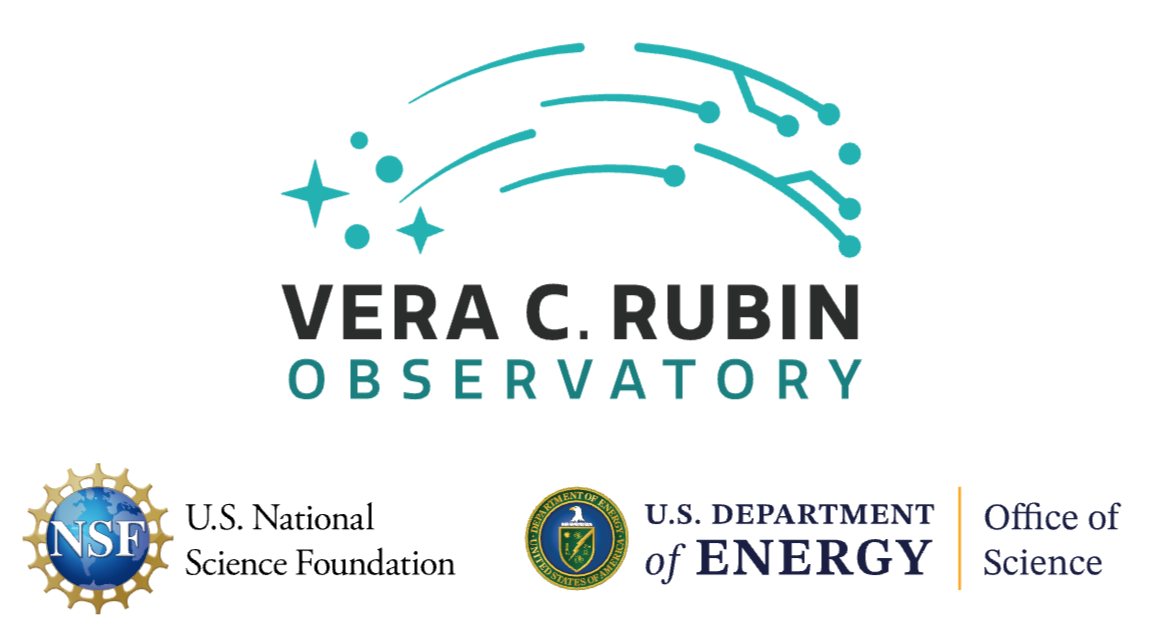

</div>

For the Rubin Science Platform at data.lsst.cloud.\
Data Release: [Data Preview 1](https://dp1.lsst.io/index.html)\
Container Size: Large\
LSST Science Pipelines version: r29.2.0\
Last verified to run: 2026-06-20\
Repository: [github.com/lsst/tutorial-notebooks](https://github.com/lsst/tutorial-notebooks)\
DOI: [10.11578/rubin/dc.20250909.20](https://doi.org/10.11578/rubin/dc.20250909.20)

**Learning objective:** Use the DP1 reliability (real/bogus) model to recalculate scores for DIA sources.

**LSST data products:** `diaSource` catalog, difference images

**Packages:** `lsst.ip.diffim`, `lsst.meas.transiNet`

**Credit:** Originally developed by the Rubin Community Science team.
Please consider acknowledging them if this notebook is used for the preparation of journal articles, software releases, or other notebooks.

**Get Support:**
Everyone is encouraged to ask questions or raise issues in the [Support Category](https://community.lsst.org/c/support) of the Rubin Community Forum.
Rubin staff will respond to all questions posted there.

## 1. Introduction

This tutorial demonstrates how to use the trained reliability model for DP1 to recalculate the reliability scores for sources in a difference image.

Difference images contain sources of residual flux (positive or negative) from the subtraction of a template from a visit image.
Real astrophysical transients, variables, and moving objects appear as difference-image sources.
Spurious sources are also present due to unavoidably imperfect template matching.
Bright stars and correlated noise are the main sources of spurious detections.
Both real and spurious DIA sources can be detected with a signal-to-noise ratio of 5.
An estimate of how likely a source is to be real, the "reliability" (also known as "real/bogus") score, is provided to enable filtering of DIA sources.

DP1 uses a relatively simple machine learning reliability model, trained on simulated data and injected point sources labeled by Rubin staff, and applied to DIA sources.
The reliability value is stored in the `reliability` column of the `DiaSource` catalog.

**Caveat:** Given that the reliability score model was trained on a relatively small and limited dataset, some caution is warranted in interpreting the `reliability` score in DP1, in particular for variable stars. Significant improvements are expected on future releases with LSSTCam data.

**Related tutorials:** The 100-level tutorial notebooks on the Butler and image display, the 200-level tutorial on the `DiaSource` catalog, and the 300-level tutorial notebooks on extragalactic transients. 

### 1.1. Import packages

Import general astronomy packages plus LSST modules.

In particular, [lsst.ip.diffim](https://pipelines.lsst.io/modules/lsst.ip.diffim/index.html) provides utilities for image differencing and transient detection, and [lsst.meas.transiNet](https://pipelines.lsst.io/modules/lsst.meas.transiNet/index.html) is an interface to the machine learning real/bogus "reliability score" classification package.

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
from astropy.table import join
from astropy.time import Time

from lsst.daf.butler import Butler, Timespan
import lsst.afw.display as afw_display
from lsst.geom import SpherePoint, degrees
import lsst.sphgeom as sphgeom
from lsst.ip.diffim import GetTemplateTask
from lsst.ip.diffim import DetectAndMeasureTask
from lsst.meas.transiNet import RBTransiNetTask, RBTransiNetConfig

### 1.2. Define parameters

Instantiate the Butler and assert that the service exists.

In [ ]:
butler = Butler("dp1", collections="LSSTComCam/DP1")
assert butler is not None

Set the backend for `afw_display` to Firefly.

In [ ]:
afw_display.setDefaultBackend("firefly")

Define the coordinates RA, Dec for the extragalactic transient [AT 2024aigg](https://www.wis-tns.org/object/2024aigg]).
This object was detected in an r-band difference image obtained on modified Julian date MJD = 60623.270468.

In [ ]:
targ_ra = 53.12476765
targ_dec = -27.73981459
targ_mjd = 60623.270468
targ_band = "r"

## 2. Retrieve data

Query the butler for visit images that overlap the target coordinates in the defined band at the specified time (in a two-minute window). There will be only one matching dataset reference (`ref`) for these narrow search constraints.

In [ ]:
delta_time = 2.0 / 60.0 / 24.0
timespan = Timespan(Time(targ_mjd - delta_time, format="mjd", scale="tai"),
                    Time(targ_mjd + delta_time, format="mjd", scale="tai"))
query = """band.name = :band AND visit.timespan OVERLAPS :timespan AND
           visit_detector_region.region OVERLAPS POINT(:ra, :dec)"""
binder = {"band": targ_band, "timespan": timespan, "ra": targ_ra, "dec": targ_dec}
del timespan, delta_time

refs = butler.query_datasets("visit_image", where=query, bind=binder)
assert len(refs) == 1
del query, binder

Get the visit and detector from the Butler dataset reference's `dataId`.

In [ ]:
targ_dataId = refs[0].dataId
targ_visit = targ_dataId["visit"]
targ_detector = targ_dataId["detector"]
print("Target visit and detector: ", targ_visit, targ_detector)

The Butler-based `dia_source` table is stored by tract (a spherical convex polygon within the LSST all-sky tessellation), not by visit and detector. Get the tract number for the target coordinates.

In [ ]:
skymap = butler.get("skyMap")
targ_tract = skymap.findTract(SpherePoint(targ_ra * degrees, targ_dec * degrees)).tract_id
print("Target tract: ", targ_tract)
del skymap

### 2.1. DIA sources

Although the TAP service is generally recommended for most catalog access, in this case the goal is to retrieve sources associated with a particular image, and the Butler is the better tool for that use-case.

Get the `dia_source` table for the identified tract. Only retrieve the few columns necessary for this tutorial.

In [ ]:
columns = ["diaSourceId", "ra", "dec", "visit", "detector", "reliability"]
dia_source = butler.get("dia_source", tract=targ_tract, parameters={"columns": columns})
print("Number of diaSources in tract: ", len(dia_source))
del columns

Down-select the `dia_source` table to only those sources detected in the targeted visit and detector.

In [ ]:
tx = np.where(dia_source["visit"] != targ_visit)[0]
dia_source.remove_rows(tx)
del tx
tx = np.where(dia_source["detector"] != targ_detector)[0]
dia_source.remove_rows(tx)
del tx
print("Number of diaSources for selected visit and detector: ", len(dia_source))

Option to display the `dia_source` table.

In [ ]:
# dia_source

Get the `diaSourceId` for the detection of the known transient in this visit and detector.

In [ ]:
targ_coord = SkyCoord(targ_ra, targ_dec, frame="icrs", unit="deg")
coords = SkyCoord(dia_source["ra"], dia_source["dec"], frame="icrs", unit="deg")
separations = coords.separation(targ_coord).arcsec
print("Known transient diaSourceId: ", dia_source["diaSourceId"][np.argmin(separations)])
targ_diaSourceId = dia_source["diaSourceId"][np.argmin(separations)]
del targ_coord, coords, separations

### 2.2. Images

Retrieve the science and difference images and display them in the Firefly tab.

In [ ]:
science = butler.get("visit_image", dataId=targ_dataId)

In [ ]:
display = afw_display.Display(frame=1)
display.image(science)

In [ ]:
difference = butler.get("difference_image", dataId=targ_dataId)

In [ ]:
display = afw_display.Display(frame=2)
display.image(difference)

Retrieve the template image.

Template coadd images are stored by tract and patch, in the same way as the deep coadd images.
However, the `RBTransiNetTask` does not take a patch of a template coadd as input -- it requires a template image that has the same bounding box and WCS as the (rotated) visit and difference images.
Thus, it is necessary to use the `GetTemplateTask` to generate this specifically-formatted template image.

First, get the bounding box (`bbox`) and world coordinate system (WCS; `wcs`) from the science image.
Use these to define a `region` on the sky within which to search for template coadd image tracts and patches that overlap the visit image.

In [ ]:
sci_bbox = science.getBBox()
sci_wcs = science.getWcs()
center_coords = sci_wcs.pixelToSky(sci_bbox.getCenterX(), sci_bbox.getCenterY())
center_ra = center_coords.getRa().asDegrees()
center_dec = center_coords.getDec().asDegrees()
region = sphgeom.Region.from_ivoa_pos(f"CIRCLE {center_ra} {center_dec} 0.2")
del center_coords, center_ra, center_dec

Retrieve the overlapping template coadd datasets from the Butler as a `set`.

In [ ]:
query = f"patch.region OVERLAPS(region) and band in ('{targ_band}')"
set_refs = set(butler.query_datasets("template_coadd", where=query,
                                     bind={"region": region}))
del query

Create a list of the overlapping template coadd datasets in the format that is desired by the `GetTemplateTask`.

In [ ]:
sorted_data = {}
for ref in set_refs:
    dataid = ref.dataId
    band_container = sorted_data.setdefault(dataid["band"], dict())
    tract_container = band_container.setdefault(dataid["tract"], list())
    tract_container.append(ref)
mapping = sorted_data[targ_band]

Create the custom template image.

In [ ]:
getTemplateTask = GetTemplateTask()
new_template = getTemplateTask.run(
    coaddExposures={tract: [butler.get(ref) for ref in refs] for tract, refs in mapping.items()},
    bbox=sci_bbox, wcs=sci_wcs, physical_filter=targ_band,
    dataIds={tract: [ref.dataId for ref in refs] for tract, refs in mapping.items()}
)

Display the template in the Firefly tab.

In [ ]:
display = afw_display.Display(frame=3)
display.image(new_template.template)

Delete what is not used any further in this tutorial.

In [ ]:
del sci_bbox, sci_wcs, region
del set_refs, sorted_data, mapping

## 3. Create an input source catalog

In the LSST Science Pipelines, the reliability scoring task `RBTransiNetTask` requires, as input, a source catalog with a different schema (format) from the `dia_source` table retrieved from the Butler.

The input it requires is the output of the `DetectAndMeasureTask` from the `lsst.ip.diffim` package (part of [Stage 4 procesing](https://dp1.lsst.io/processing/summary/index.html#stage-4)).
This output is an *intermediate* table, only used in between steps of the pipeline.
It has different columns and will have addition rows (sources that are initially detected, but rejected by later steps of the pipelines before the final `dia_source` table is created).

The quickest and simplest way to create the correct input source table for the reliability scoring task is to rerun source detection on the difference image.

First, remove and clear the "DETECTED" mask plane of the difference image.

In [ ]:
difference.mask.removeAndClearMaskPlane("DETECTED")

Use the standard configuration to define the `DetectAndMeasureTask`, then pass the science, template, and difference image to its `run` method. Retrieve the sources from the result.

In [ ]:
config = DetectAndMeasureTask.ConfigClass()
detect_task = DetectAndMeasureTask(config=config)
results = detect_task.run(science, new_template.template, difference)
sources = results.diaSources
del config, detect_task, results

## 4. Recalculate reliability scores

The model package for the DP1 reliability score must be in a directory with the name `model_packages/<model_name>`, which in turn must be in `MEAS_TRANSINET_DIR`.

The trained machine-learning model for the reliability score for DP1 is named `tac_cnn_comcam_2025-02-18`, and has been provided in the directory path defined in the following cell.

In [ ]:
path = "/rubin/cst_repos/tutorial-notebooks-data/data/reliability_score_dp1"
os.environ["MEAS_TRANSINET_DIR"] = path
del path

Configure the `RBTransiNetTask`.

In [ ]:
config = RBTransiNetConfig()
config.modelPackageName = "tac_cnn_comcam_2025-02-18"
config.modelPackageStorageMode = "local"
reliabilityTask = RBTransiNetTask(config=config)
del config

Run the task by passing it the template, science, and difference images, and the sources table.
Extract the reliability scores (classifications) as an `astropy` table.

In [ ]:
results = reliabilityTask.run(new_template.template, science, difference,
                              sources, pretrainedModel=None)
rb_table = results.classifications.asAstropy()
del results

Use the `astropy.table.join` module to add the column `score` from `rb_table` to the `sources` table.

In [ ]:
sources = sources.copy(True).asAstropy()
sources = join(sources, rb_table, keys="id")
del rb_table

Option to view the `sources` table.

In [ ]:
# sources

## 5. Explore the results

### 5.1. Cross-match

Convert the `sources` table coordinates from radians to degrees, and use the `astropy` `SkyCoord` module to find the nearest row of the `dia_source` table (within 1 arcsecond), and save the matching row index as a new column in the `sources` table.

In [ ]:
sources["ra_deg"] = np.rad2deg(sources["coord_ra"])
sources["dec_deg"] = np.rad2deg(sources["coord_dec"])
sources["dias_x"] = np.zeros(len(sources), dtype="int") - 1

dia_source_coords = SkyCoord(dia_source["ra"], dia_source["dec"], frame="icrs", unit="deg")

for source in sources:
    coords = SkyCoord(source["ra_deg"], source["dec_deg"], frame="icrs", unit="deg")
    separations = coords.separation(dia_source_coords).arcsec
    if np.min(separations) < 1.0:
        source["dias_x"] = np.argmin(separations)
    del coords, separations

del dia_source_coords

Every row of the `dia_source` table should be uniquely matched to a row of the `sources` table.
The `sources` table will have a few unmatched rows, representing detections that are later rejected and not reported as DP1 DIA sources.

This means the number of unique values of the `dias_x` column should be equal to the length of the `dia_source` table, plus one (the extra unique value being -1, the value for an unmatched row of the `sources` table).
Show that this is the case.

In [ ]:
print("Length of the dia_source table: ", len(dia_source))
values = np.unique(sources["dias_x"])
assert len(values) == len(dia_source) + 1
print("Number of unqiue values of dias_x: ", len(values))
del values
tx = np.where(sources["dias_x"] < 0)[0]
print("Number of unmatched sources: ", len(tx))
del tx

### 5.2. Compare scores

Use the `diaSourceId` of the known transient defined in Section 1.2 to show that the original and recalculated reliability scores are the same for this particular source.

In [ ]:
tx = np.where(dia_source["diaSourceId"] == targ_diaSourceId)[0]
ix = np.where(sources["dias_x"] == tx)[0]
print("The transient's original reliability: ", dia_source["reliability"][tx[0]])
print("The transient's recalculated reliability: ", sources["score"][ix[0]])
del tx, ix

Compare all original and recalculated reliability scores, and notice that when there is a difference, it is very very small.

In [ ]:
fig = plt.figure(figsize=(6, 4))
tx = np.where(sources["dias_x"] >= 0)[0]
for source in sources[tx]:
    xval = dia_source["reliability"][source["dias_x"]]
    yval = xval - source["score"]
    plt.plot(xval, yval, "o", ms=5, alpha=0.5, color="grey", mew=0)
    if dia_source["diaSourceId"][source["dias_x"]] == targ_diaSourceId:
        plt.plot(xval, yval, "*", ms=10, alpha=1, color="None", mec="cyan")
    del xval, yval
plt.xlabel("Original Reliability")
plt.ylabel("Original - Recalculated Reliability")
plt.show()
del tx

> **Figure 1:** The original reliability vs. the difference between the original and the recalculated variability, for all rows of the `source` table that are matched to the `dia_source` table. The known extragalactic transient is marked with a cyan star. Overall, when there are differences between the original and recalculated reliability score, they are very small.

### 5.3. Mark sources on image

Mark the locations from the `source` table on the difference image.

Switch the `display` back to frame 2, which shows the difference image, and set the mask transparency to 100 (totally transparent mask).

In [ ]:
display = afw_display.Display(frame=2)
display.setMaskTransparency(100)

Mark the locations of the sources in the `source` table with orange circles - or red if it is one of the unmatched sources, and cyan if it is the known extragalactic transient.

In [ ]:
with display.Buffering():
    for source in sources:
        clr = "orange"
        if source["dias_x"] < 0:
            clr = "red"
        elif dia_source["diaSourceId"][source["dias_x"]] == targ_diaSourceId:
            clr = "cyan"
        display.dot("o", source["base_SdssCentroid_x"],
                    source["base_SdssCentroid_y"],
                    size=20, ctype=clr)

<div style="max-width:500px; float: left; margin-right: 1em">

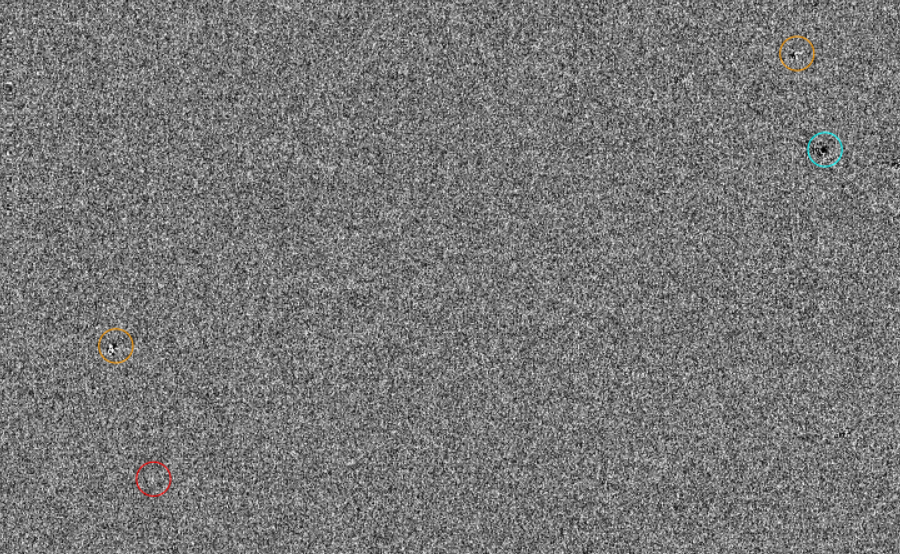

</div>

> **Figure 2:** A zoom in on the difference image in panel 2 of the Firefly display, with `sources` marked in orange, the known transient detection marked in cyan, and `sources` unmatched to the `dia_source` table (rejected detections) in red.